In [3]:
# ======================================================
# Análisis de datos faltantes por columna
# ======================================================

import pandas as pd
import numpy as np

# Ruta del archivo (ya existente en tu entorno de Colab)
ruta = "/content/base_datos_completa_NNA_TI_anon (1).xlsx"

# ------------------------------------------------------
# 1) Leer el archivo Excel (primera hoja por defecto)
# ------------------------------------------------------
try:
    df = pd.read_excel(ruta, sheet_name=0, dtype="object")
    print("✅ Archivo leído correctamente.")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
except Exception as e:
    raise RuntimeError(f"Error al leer el archivo: {e}")

# ------------------------------------------------------
# 2) Normalizar valores faltantes comunes
# ------------------------------------------------------
valores_faltantes = [
    "", " ", "-", "--", "---",
    "na", "n/a", "na/", "nan", "null", "none",
    "sin dato", "s/d", "sd", "no aplica", "n/a.", ".", "?"
]

def limpiar_na(x):
    if isinstance(x, str):
        s = x.strip().lower()
        if s in valores_faltantes:
            return np.nan
        if s == "":
            return np.nan
    return x

df = df.applymap(limpiar_na)

# ------------------------------------------------------
# 3) Calcular número y porcentaje de faltantes
# ------------------------------------------------------
n_total = len(df)
faltantes = df.isna().sum()
porcentaje = (faltantes / n_total * 100).round(2)

tabla_faltantes = (
    pd.DataFrame({
        "Columna": df.columns,
        "N_faltantes": faltantes.values,
        "Porcentaje": porcentaje.values
    })
    .sort_values(by="Porcentaje", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------
# 4) Mostrar resultados
# ------------------------------------------------------
print("\n=== Datos faltantes por columna ===")
display(tabla_faltantes)

# ------------------------------------------------------
# 5) (Opcional) Exportar resultados a Excel
# ------------------------------------------------------
salida = "/content/faltantes_por_columna.xlsx"
tabla_faltantes.to_excel(salida, index=False)
print(f"\n📂 Resultados guardados en: {salida}")


✅ Archivo leído correctamente.
Filas: 56473 | Columnas: 115


/tmp/ipython-input-323750206.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_na)



=== Datos faltantes por columna ===


,Columna,N_faltantes,Porcentaje
0,CATEGORÍAS DE LA DISCAPACIDAD,56300,99.69
1,ADOLESCENTE TRABAJO PROTEGIDO.1,14748,26.12
2,ADOLESCENTE TRABAJO PROTEGIDO,11919,21.11
3,CUMPLIÓ,338,0.60
4,CUMPLIÓ.3,223,0.39
...,...,...,...
110,CLASIFICACIÓN NUTRICIONAL,0,0.00
111,Sub-Sección => RESULTADOS DE LA INTERVENCIÓN,0,0.00
112,"Sub-Sección => Intervención de Niño, Niña o Ad...",0,0.00
113,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR S...,0,0.00



📂 Resultados guardados en: /content/faltantes_por_columna.xlsx


In [ ]:
# ======================================================
# Limpieza integral de base + vista final (con doble dedup)
# ======================================================

!pip install unidecode openpyxl --quiet

import pandas as pd
import numpy as np
import re, warnings
from dateutil.parser import parse as dtparse
from unidecode import unidecode

# --------------------------
# Parámetros
# --------------------------
RUTA = "/content/base_datos_completa_NNA_TI_anon (1).xlsx"
SHEET_INDEX = 0
THRESH_COL_NA_DROP = 0.50
THRESH_CONST_UNIQUE = 1
DATE_SUCCESS_RATE = 0.80
NUM_SUCCESS_RATE = 0.90

NA_STRINGS = {
    "", " ", "-", "--", "---", ".", "?", "#N/A", "#NA",
    "na", "n/a", "na/", "nan", "null", "none", "nil",
    "sin dato", "s/d", "sd", "no aplica", "n.a", "n.a.", "na.", "n.d."
}
BOOL_TRUE = {"si", "sí", "true", "t", "verdadero", "v", "1", "x"}
BOOL_FALSE = {"no", "false", "f", "falso", "0"}

warnings.filterwarnings("ignore", message="Could not infer format")  # silencia avisos de fechas

# --------------------------
# Auxiliares
# --------------------------
def dedup_columns(cols):
    """Hace únicos los nombres de columnas duplicadas conservando el orden."""
    seen = {}
    new_cols = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            new_cols.append(c)
    return new_cols

def norm_colname(name: str) -> str:
    s = unidecode(str(name)).strip().lower()
    s = re.sub(r"[^\w]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "col"

def to_na_cell(x):
    if isinstance(x, str):
        s = x.strip().lower()
        if s in NA_STRINGS or s == "":
            return np.nan
    return x

def try_parse_bool_series(s: pd.Series):
    if not isinstance(s, pd.Series) or s.ndim != 1:
        return None
    sm = s.dropna()
    if sm.empty:
        return None
    sm = sm.astype(str).str.strip().str.lower()
    uniq = set(sm.unique())
    if uniq.issubset(BOOL_TRUE.union(BOOL_FALSE)):
        return s.map(lambda z: True if str(z).strip().lower() in BOOL_TRUE else (
            False if str(z).strip().lower() in BOOL_FALSE else np.nan))
    return None

def try_parse_number_series(s: pd.Series, rate=NUM_SUCCESS_RATE):
    if not isinstance(s, pd.Series) or s.ndim != 1:
        return None
    sm = s.dropna().astype(str).head(3000)
    if sm.empty:
        return None
    def conv(v):
        v = re.sub(r"[^\d,.\-]", "", v)
        if "," in v and "." in v:
            if v.rfind(",") > v.rfind("."):
                v = v.replace(".", "").replace(",", ".")
            else:
                v = v.replace(",", "")
        elif "," in v:
            v = v.replace(".", "").replace(",", ".")
        try:
            return float(v)
        except:
            return None
    parsed = sm.map(conv)
    if parsed.notna().mean() >= rate:
        return s.map(lambda z: conv(str(z)) if pd.notna(z) else np.nan)
    return None

def try_parse_date_series(s: pd.Series, rate=DATE_SUCCESS_RATE):
    if not isinstance(s, pd.Series) or s.ndim != 1:
        return None
    sm = s.dropna().astype(str).head(3000)
    if sm.empty:
        return None
    def safe_parse(z):
        try:
            return dtparse(z, dayfirst=True, fuzzy=True)
        except:
            return None
    parsed = sm.map(safe_parse)
    if parsed.notna().mean() >= rate:
        return pd.to_datetime(s, errors="coerce", dayfirst=True)
    return None

def is_constant_series(s: pd.Series, thresh=THRESH_CONST_UNIQUE):
    """Devuelve True si la columna tiene <= thresh valores no nulos distintos.
       Blinda si por error llega un DataFrame (por duplicados)."""
    if isinstance(s, pd.DataFrame):
        # de existir, nos quedamos con la primera subcolumna para decidir
        s = s.iloc[:, 0]
    return s.dropna().nunique() <= thresh

# --------------------------
# 1) Leer datos
# --------------------------
df = pd.read_excel(RUTA, sheet_name=SHEET_INDEX, dtype="object")
print(f"✅ Archivo leído: {RUTA}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

# Deduplicar (1) usando los nombres originales
df.columns = dedup_columns(df.columns)

# --------------------------
# 2) Limpieza básica
# --------------------------
# Normaliza nombres
df.columns = [norm_colname(c) for c in df.columns]

# Deduplicar (2) tras normalizar (¡clave para evitar ambigüedades!)
df.columns = dedup_columns(df.columns)

# Normaliza celdas NA (usa DataFrame.map en pandas 2.x)
df = df.map(to_na_cell)

# --------------------------
# 3) Conversión de tipos
# --------------------------
conversions = []
for col in df.columns:
    s = df[col]
    # Bool
    s_bool = try_parse_bool_series(s)
    if s_bool is not None:
        df[col] = s_bool
        conversions.append((col, "bool"))
        continue
    # Numérico
    s_num = try_parse_number_series(s)
    if s_num is not None:
        df[col] = s_num
        conversions.append((col, "numeric"))
        continue
    # Fecha
    s_date = try_parse_date_series(s)
    if s_date is not None:
        df[col] = s_date
        conversions.append((col, "datetime"))

# --------------------------
# 4) Eliminar columnas (>50% NA) o constantes
# --------------------------
cols_drop_na = [c for c in df.columns if df[c].isna().mean() > THRESH_COL_NA_DROP]
cols_const = [c for c in df.columns if is_constant_series(df[c], THRESH_CONST_UNIQUE)]
cols_to_drop = sorted(set(cols_drop_na + cols_const))

df_clean = df.drop(columns=cols_to_drop) if cols_to_drop else df.copy()

print(f"\n🧹 Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")

# --------------------------
# 5) Resumen y vista
# --------------------------
print(f"\n✅ Limpieza completada.")
print(f"Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")
print(f"Conversiones de tipo realizadas: {conversions if conversions else 'Ninguna'}")

print("\n=== Vista previa de los datos limpios ===")
display(df_clean.head(10))

# --------------------------
# 6) Exportar resultados
# --------------------------
df_clean.to_excel("/content/base_limpia.xlsx", index=False)
print("\n📁 Archivo exportado: /content/base_limpia.xlsx")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.6 MB/s eta 0:00:00
✅ Archivo leído: /content/base_datos_completa_NNA_TI_anon (1).xlsx
Filas: 56473 | Columnas: 115

🧹 Columnas eliminadas (38): ['acompanamiento_2', 'acompanamiento_3', 'acompanamiento_4', 'adolescente_trabajo_protegido', 'adolescente_trabajo_protegido_1', 'afiliacion_al_sgsss', 'afiliacion_al_sgsss_1', 'categorias_de_la_discapacidad', 'curso_de_vida', 'direccion_de_la_vivienda', 'estado_civil', 'estrato', 'estrato_socioeconomico', 'etnia', 'genero', 'idniveleducativo', 'localidad', 'localidad_1', 'nna_desvinculado_de_la_actividad_laboral_1', 'numero_de_manzana_del_cuidado', 'numero_de_manzana_del_cuidado_1', 'poblacion_diferencial_y_de_inclusion', 'pueblo', 'razonabandonoescolar', 'sexo', 'sub_seccion_informacion_del_acudiente', 'sub_seccion_informacion_del_menor_nna_identificado_como_trabajador', 'sub_seccion_informacion_laboral', 'sub_seccion_intervencion_de_nino_nina_o_adolescente', 'sub_seccion_resultados

,id_fic,base_origen,ficha_fic,fecha_intervencion,localidad_fic,red_fic,usuario,perfil,informacion_del_menor,nacionalidad,...,etapa_de_gestacion,acudiente_autoriza_verificacion_o_toma_de_peso_y_talla,peso,talla_cm,clasificacion_nutricional,requiere_asesoria_de_nutricion,intervencion_de_nino_nina_o_adolescente_que_termina_el_proceso,fecha_seguimiento_cierre,nna_desvinculado_de_la_actividad_laboral,fecha_reposicion_de_psicologo_o_trabajador_social_posterior_al_seguimiento_cierre
0,1977498.0,2425.0,3.190245e+09,2024-12-05,Ciudad Bolívar,Sur,rapalencia,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,10000.0,69.0,Sobrepeso infantil,Si,Si,2025-02-21,No,2023-10-13
1,1977499.0,2425.0,3.190245e+09,2024-12-05,Ciudad Bolívar,Sur,estellez,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,12.6,97.0,Acorde para la edad/talla,No,Si,2025-02-21,Si,2023-10-13
2,1977500.0,2425.0,3.190245e+09,2024-12-05,Ciudad Bolívar,Sur,fecelis,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,21.5,124.0,Acorde para la edad/talla,No,Si,2025-02-21,Si,2023-10-13
3,1977544.0,2425.0,3.060245e+09,2024-12-04,Tunjuelito,Sur,smroncancio,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,18.0,108.0,Acorde para la edad/talla,No,Si,2025-02-26,Si,2023-10-13
4,1977549.0,2425.0,3.190245e+09,2024-12-05,Ciudad Bolívar,Sur,rapalencia,Tecnólogo en Salud Ocupacional,99999.0,Venezuela (Bolivarian Republic of),...,99999,Si,28.5,135.0,Acorde para la edad/talla,No,Si,2025-02-21,No,2023-10-13
5,1977554.0,2425.0,3.060245e+09,2024-12-06,Tunjuelito,Sur,estellez,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,28.3,140.0,Acorde para la edad/talla,No,Si,2025-02-27,Si,2023-10-13
6,1977555.0,2425.0,3.060245e+09,2024-12-06,Tunjuelito,Sur,fecelis,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,28.2,143.0,Acorde para la edad/talla,No,Si,2025-02-27,Si,2023-10-13
7,1977594.0,2425.0,3.060245e+09,2024-12-06,Tunjuelito,Sur,rapalencia,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,38.7,138.0,Acorde para la edad/talla,No,Si,2025-02-25,Si,2023-10-13
8,1977596.0,2425.0,3.060245e+09,2024-12-06,Tunjuelito,Sur,estellez,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,23.1,32.0,Acorde para la edad/talla,No,Si,2025-02-27,Si,2023-10-13
9,1977598.0,2425.0,3.060245e+09,2024-12-06,Tunjuelito,Sur,fecelis,Tecnólogo en Salud Ocupacional,99999.0,Colombia,...,99999,Si,12.0,88.0,Acorde para la edad/talla,No,Si,2025-02-27,Si,2023-10-13


✅ Base cargada: 56473 filas, 77 columnas

🔍 Posibles variables relevantes: ['fecha_intervencion', 'perfil', 'fecha_de_la_ultima_intervencion', 'acompanamiento_1_perfil', 'perfil_1', 'perfil_2', 'perfil_3', 'intervencion_de_nino_nina_o_adolescente_que_termina_el_proceso', 'nna_desvinculado_de_la_actividad_laboral']

Usando columnas: PERFIL=perfil, INTERVENCIÓN=fecha_intervencion, DESVINCULACIÓN=nna_desvinculado_de_la_actividad_laboral
✅ Filtrado: quedan 4661 registros tras eliminar perfil 99999


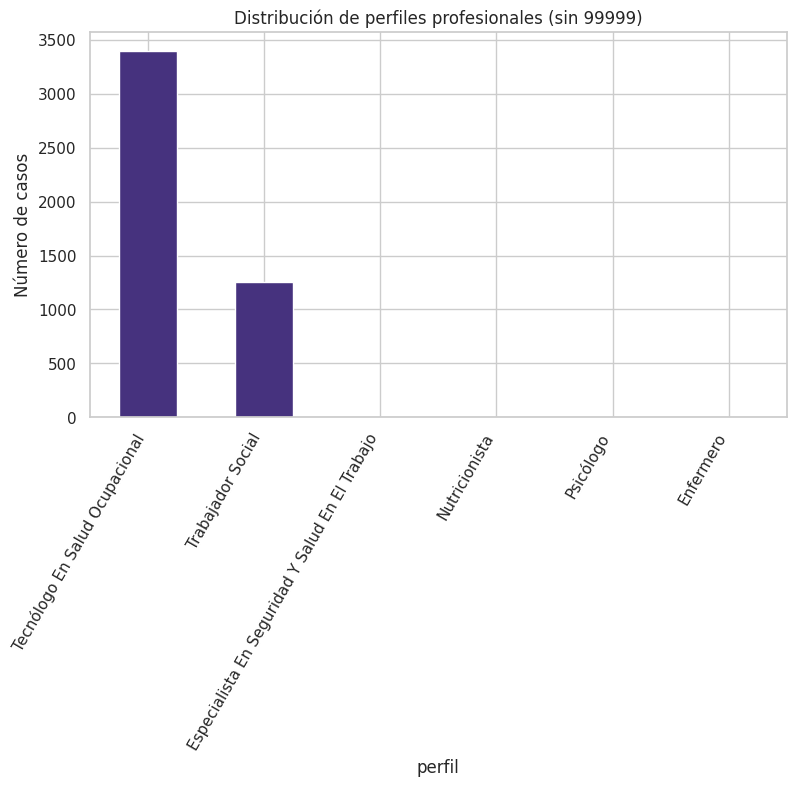

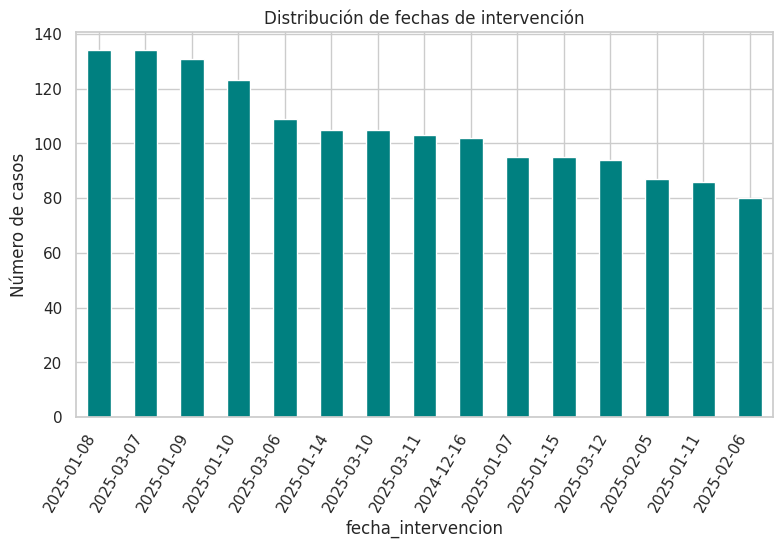

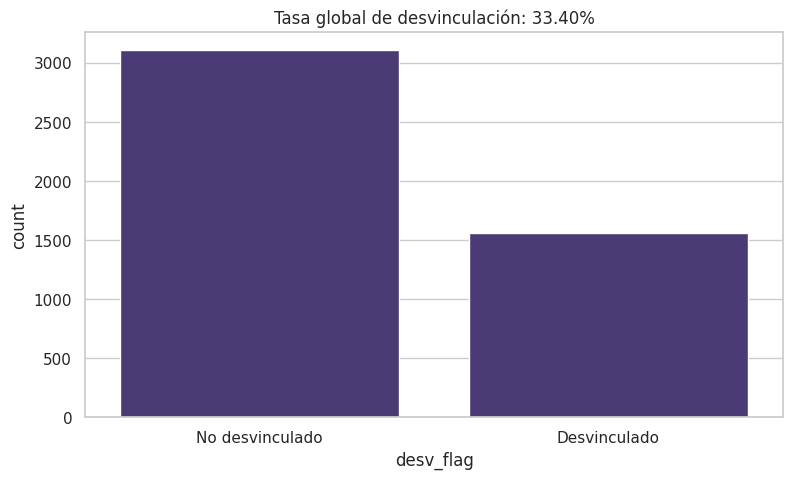


📊 Tasa de desvinculación por tipo de intervención:


,count,sum,tasa
fecha_intervencion,,,
2024-12-04,14,14,100.000000
2024-12-08,1,1,100.000000
2025-01-19,2,2,100.000000
2025-03-30,4,4,100.000000
2025-02-23,11,11,100.000000
2024-12-06,62,51,82.258065
2024-12-16,102,83,81.372549
2024-12-13,44,35,79.545455
2024-12-10,60,47,78.333333


/tmp/ipython-input-3746432858.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




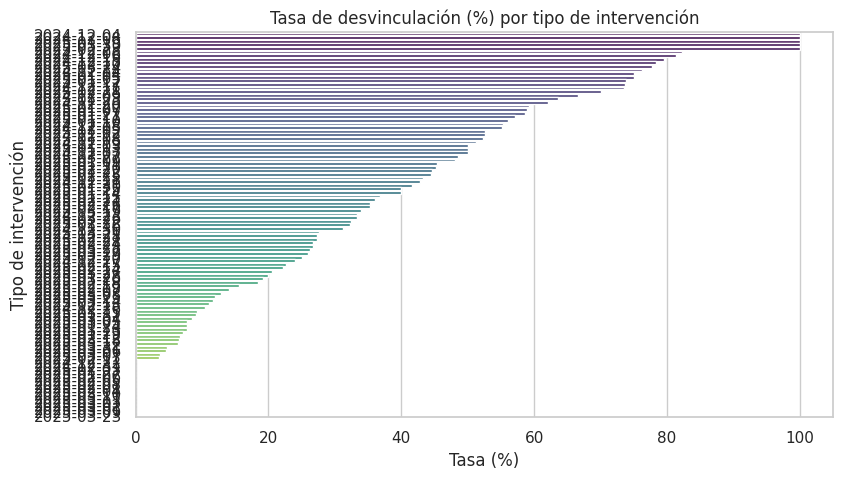

/tmp/ipython-input-3746432858.py:113: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




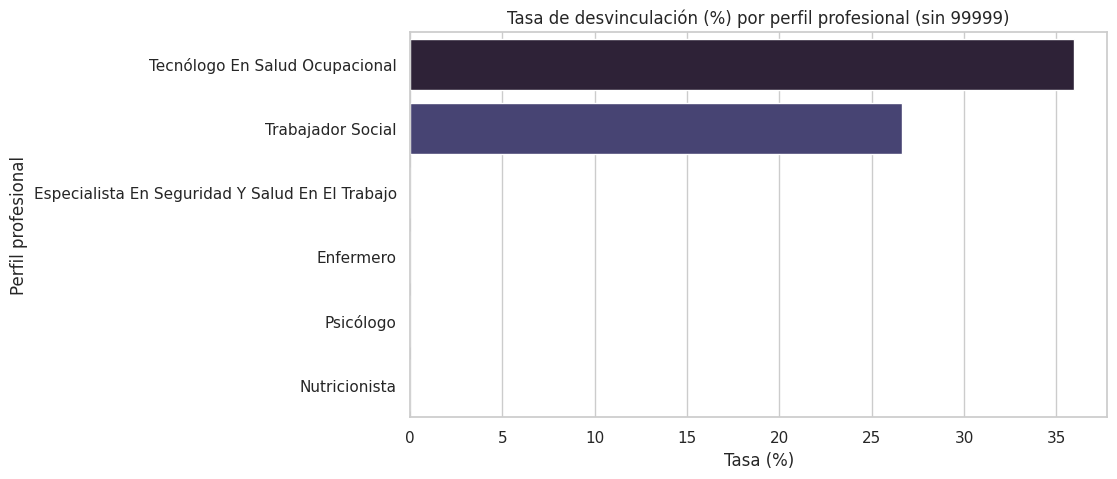

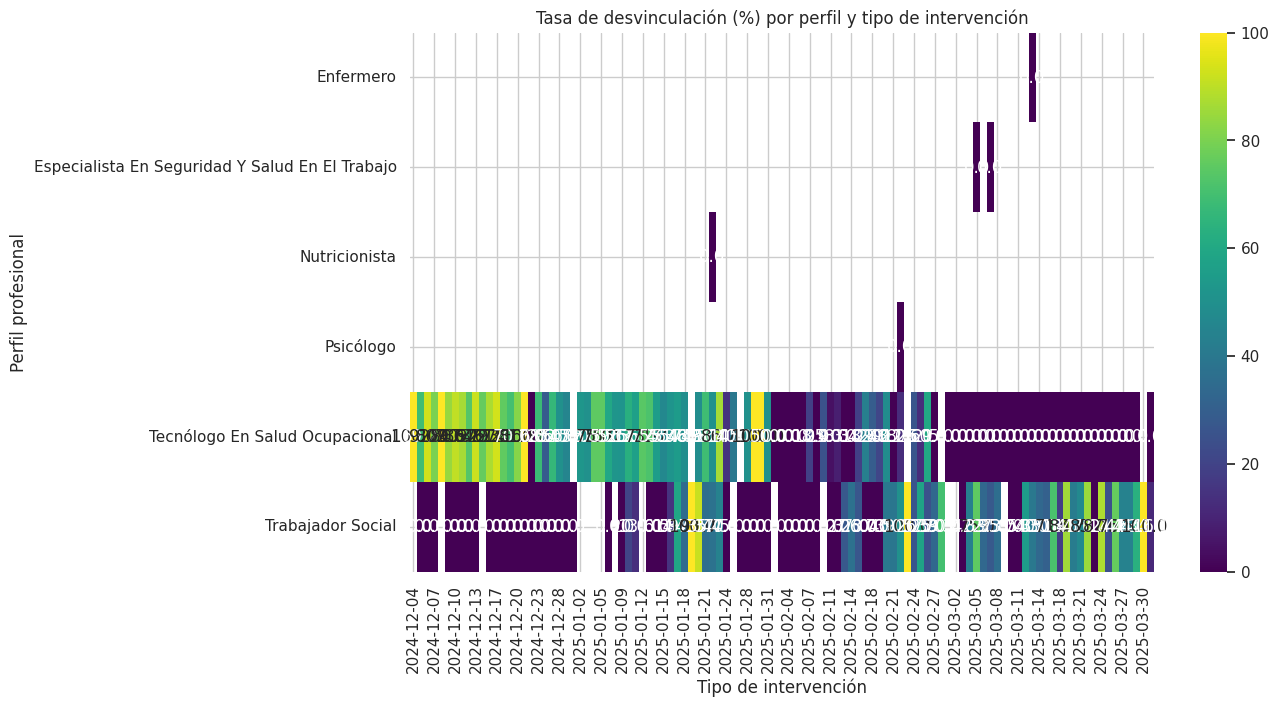


=== INSIGHTS PRELIMINARES ===
📈 Tasa global de desvinculación: 33.40%
👉 Intervenciones con mayor tasa de desvinculación:


,count,sum,tasa
fecha_intervencion,,,
2024-12-04,14,14,100.0
2024-12-08,1,1,100.0
2025-01-19,2,2,100.0
2025-03-30,4,4,100.0
2025-02-23,11,11,100.0


👉 Perfiles profesionales con mayor tasa de éxito:


,count,sum,tasa
perfil,,,
Tecnólogo En Salud Ocupacional,3401,1223,35.960012
Trabajador Social,1255,334,26.613546
Especialista En Seguridad Y Salud En El Trabajo,2,0,0.000000
Enfermero,1,0,0.000000
Psicólogo,1,0,0.000000


In [ ]:
# ======================================================
# Exploratory Data Analysis (EDA) – Desvinculación TI
# Excluyendo perfil profesional = 99999
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuración estética
plt.rcParams['figure.figsize'] = (9,5)
sns.set(style="whitegrid", palette="viridis", font_scale=1.0)

# -------------------------------
# 1) Cargar datos limpios
# -------------------------------
ruta = "/content/base_limpia.xlsx"
df = pd.read_excel(ruta)
print(f"✅ Base cargada: {df.shape[0]} filas, {df.shape[1]} columnas")

# -------------------------------
# 2) Identificar columnas relevantes
# -------------------------------
cols = df.columns.str.lower()
posibles_cols = [c for c in cols if any(x in c for x in ["perfil", "interv", "desvinc"])]
print("\n🔍 Posibles variables relevantes:", posibles_cols)

# Asignar nombres esperados (ajústalos según tu base)
col_perfil = next((c for c in df.columns if "perfil" in c.lower()), None)
col_interv = next((c for c in df.columns if "interv" in c.lower()), None)
col_desv   = next((c for c in df.columns if "desvinc" in c.lower()), None)

if not all([col_perfil, col_interv, col_desv]):
    raise ValueError("⚠️ No se pudieron detectar columnas clave. Revisa los nombres y ajústalos manualmente.")

print(f"\nUsando columnas: PERFIL={col_perfil}, INTERVENCIÓN={col_interv}, DESVINCULACIÓN={col_desv}")

# -------------------------------
# 3) Limpieza mínima
# -------------------------------
for c in [col_perfil, col_interv, col_desv]:
    df[c] = (df[c].astype(str)
                  .str.strip()
                  .str.title()
                  .replace({"Nan": np.nan, "": np.nan, "None": np.nan}))

# Filtrar perfil != 99999 (como texto o número)
df = df[~df[col_perfil].isin(["99999", "99 999", 99999, 99999.0])].copy()
print(f"✅ Filtrado: quedan {len(df)} registros tras eliminar perfil 99999")

# Codificar la variable de desvinculación a 0/1
map_desv = {"Si":1, "Sí":1, "1":1, "True":1, "No":0, "0":0, "False":0}
df["desv_flag"] = df[col_desv].map(map_desv)
df["desv_flag"] = df["desv_flag"].fillna(0).astype(int)

# -------------------------------
# 4) Univariado
# -------------------------------

# a) Perfil profesional
plt.figure()
df[col_perfil].value_counts().head(15).plot(kind="bar")
plt.title("Distribución de perfiles profesionales (sin 99999)")
plt.ylabel("Número de casos")
plt.xticks(rotation=60, ha="right")
plt.show()

# b) Tipo de intervención
plt.figure()
df[col_interv].value_counts().head(15).plot(kind="bar", color="teal")
plt.title("Distribución de fechas de intervención")
plt.ylabel("Número de casos")
plt.xticks(rotation=60, ha="right")
plt.show()

# c) Desvinculación general
desv_rate = df["desv_flag"].mean()*100
sns.countplot(x="desv_flag", data=df)
plt.title(f"Tasa global de desvinculación: {desv_rate:.2f}%")
plt.xticks([0,1], ["No desvinculado","Desvinculado"])
plt.show()

# -------------------------------
# 5) Bivariado
# -------------------------------

# a) Tasa por tipo de intervención
tasa_interv = (
    df.groupby(col_interv)["desv_flag"]
      .agg(["count","sum"])
      .assign(tasa=lambda x: 100*x["sum"]/x["count"])
      .sort_values("tasa", ascending=False)
)
print("\n📊 Tasa de desvinculación por tipo de intervención:")
display(tasa_interv.head(10))

plt.figure()
sns.barplot(x="tasa", y=tasa_interv.index, data=tasa_interv.reset_index(), palette="viridis")
plt.title("Tasa de desvinculación (%) por tipo de intervención")
plt.xlabel("Tasa (%)"); plt.ylabel("Tipo de intervención")
plt.show()

# b) Tasa por perfil profesional
tasa_perfil = (
    df.groupby(col_perfil)["desv_flag"]
      .agg(["count","sum"])
      .assign(tasa=lambda x: 100*x["sum"]/x["count"])
      .sort_values("tasa", ascending=False)
)
plt.figure()
sns.barplot(x="tasa", y=tasa_perfil.index, data=tasa_perfil.reset_index(), palette="mako")
plt.title("Tasa de desvinculación (%) por perfil profesional (sin 99999)")
plt.xlabel("Tasa (%)"); plt.ylabel("Perfil profesional")
plt.show()

# c) Mapa de calor cruzando ambos
pivot = pd.pivot_table(df, values="desv_flag",
                       index=col_perfil, columns=col_interv, aggfunc="mean")
plt.figure(figsize=(12,7))
sns.heatmap(pivot*100, annot=True, fmt=".1f", cmap="viridis")
plt.title("Tasa de desvinculación (%) por perfil y tipo de intervención")
plt.xlabel("Tipo de intervención"); plt.ylabel("Perfil profesional")
plt.show()

# -------------------------------
# 6) Interacciones adicionales
# -------------------------------
fig = px.scatter(df,
                 x=col_perfil, y=col_interv,
                 color=df["desv_flag"].map({1:"Desvinculado",0:"No desvinculado"}),
                 title="Casos por perfil e intervención (color = desvinculación)",
                 opacity=0.6)
fig.update_traces(marker=dict(size=8))
fig.show()

# -------------------------------
# 7) Insights rápidos
# -------------------------------
print("\n=== INSIGHTS PRELIMINARES ===")
print(f"📈 Tasa global de desvinculación: {desv_rate:.2f}%")
print("👉 Intervenciones con mayor tasa de desvinculación:")
display(tasa_interv.head(5))
print("👉 Perfiles profesionales con mayor tasa de éxito:")
display(tasa_perfil.head(5))


✅ Base cargada: 56473 filas, 77 columnas

📍 Variables: LOCALIDAD=localidad_fic, DESVINCULACIÓN=nna_desvinculado_de_la_actividad_laboral, INTERVENCIÓN=fecha_intervencion

📊 Indicadores por zona:


,casos,desvinculados,tasa_desv,prevalencia
localidad_fic,,,,
Ciudad Bolívar,7957,4767,59.909514,14.089919
Bosa,5774,3785,65.552477,10.224355
Kennedy,5431,3597,66.230897,9.616985
Suba,4931,3418,69.316569,8.731606
Usme,3930,2966,75.470738,6.959078
Engativá,3810,2653,69.632546,6.746587
Rafael Uribe Uribe,3168,1949,61.521465,5.609760
Los Mártires,3161,1968,62.258779,5.597365
San Cristóbal,3106,1950,62.781713,5.499973



🔥 Zonas con mayor riesgo (alta prevalencia y baja efectividad):


,casos,desvinculados,tasa_desv,prevalencia,z_prevalencia,z_tasa_desv,riesgo
localidad_fic,,,,,,,
Ciudad Bolívar,7957,4767,59.909514,14.089919,1.000000,0.793811,0.206189
Bosa,5774,3785,65.552477,10.224355,0.725616,0.868581,0.095359
Kennedy,5431,3597,66.230897,9.616985,0.682504,0.877571,0.083559
Rafael Uribe Uribe,3168,1949,61.521465,5.609760,0.398064,0.815170,0.073574
Los Mártires,3161,1968,62.258779,5.597365,0.397185,0.824939,0.069531
San Cristóbal,3106,1950,62.781713,5.499973,0.390271,0.831868,0.065617
Antonio Nariño,2067,1205,58.297049,3.660156,0.259678,0.772446,0.059091
Santa Fe,2809,1792,63.794945,4.974058,0.352941,0.845294,0.054602
Barrios Unidos,2670,1698,63.595506,4.727923,0.335470,0.842651,0.052786


🗺️ No hay coordenadas, geocodificando nombres de zonas...


/tmp/ipython-input-2880327278.py:115: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




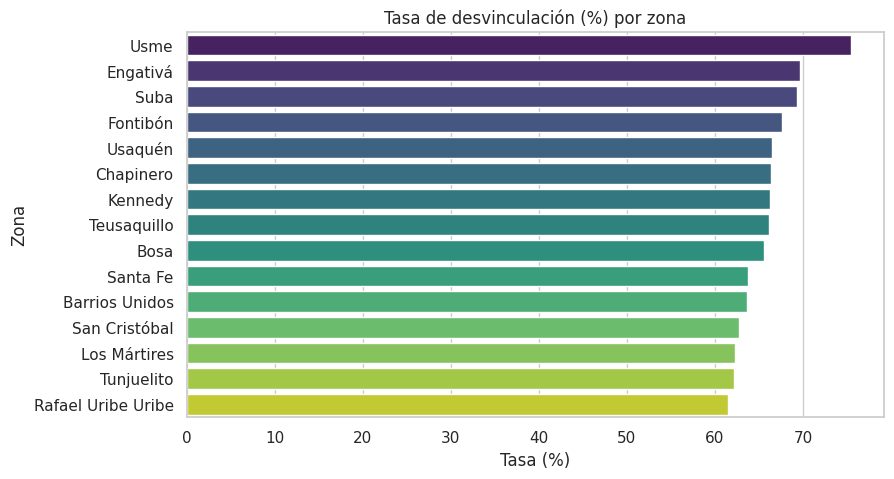

/tmp/ipython-input-2880327278.py:121: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




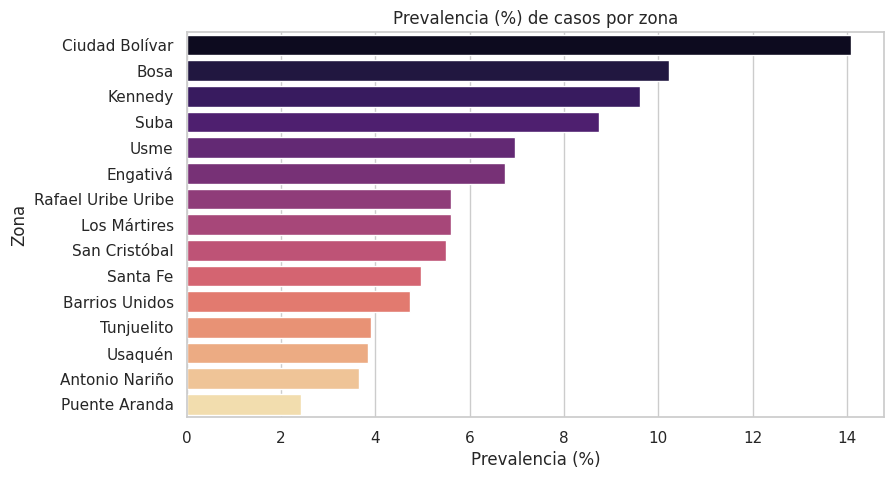

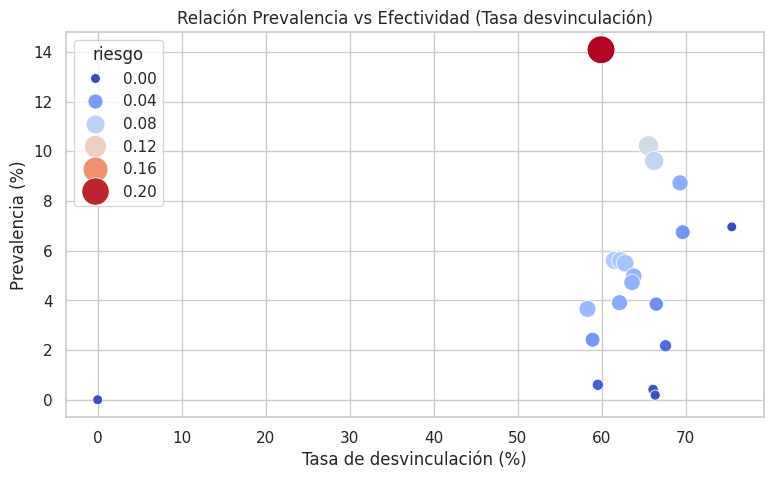

In [ ]:
# ======================================================
# EDA + GEOREFERENCIACIÓN DE RIESGO
# ======================================================

!pip install geopandas geopy folium plotly --quiet

import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from folium import Choropleth, CircleMarker, LayerControl
from geopy.geocoders import Nominatim
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

# Configuración estética
plt.rcParams['figure.figsize'] = (9,5)
sns.set(style="whitegrid", palette="magma", font_scale=1.0)

# -------------------------------
# 1) Cargar datos
# -------------------------------
ruta = "/content/base_limpia.xlsx"
df = pd.read_excel(ruta)
print(f"✅ Base cargada: {df.shape[0]} filas, {df.shape[1]} columnas")

# -------------------------------
# 2) Detección de columnas clave
# -------------------------------
cols = df.columns.str.lower()
col_loc = next((c for c in df.columns if "local" in c.lower() or "municip" in c.lower()), None)
col_desv = next((c for c in df.columns if "desvinc" in c.lower()), None)
col_interv = next((c for c in df.columns if "interv" in c.lower()), None)

if not all([col_loc, col_desv]):
    raise ValueError("⚠️ No se detectaron columnas de ubicación o desvinculación. Ajusta manualmente col_loc y col_desv.")

print(f"\n📍 Variables: LOCALIDAD={col_loc}, DESVINCULACIÓN={col_desv}, INTERVENCIÓN={col_interv}")

# -------------------------------
# 3) Preparación de variables
# -------------------------------
df[col_loc] = df[col_loc].astype(str).str.strip().str.title()
df[col_desv] = df[col_desv].astype(str).str.strip().str.lower()

map_desv = {"si":1, "sí":1, "1":1, "true":1, "no":0, "0":0, "false":0}
df["desv_flag"] = df[col_desv].map(map_desv).fillna(0).astype(int)

# -------------------------------
# 4) Agregación por zona
# -------------------------------
zona_stats = (
    df.groupby(col_loc)
      .agg(
          casos=("desv_flag","count"),
          desvinculados=("desv_flag","sum")
      )
      .assign(
          tasa_desv=lambda x: 100 * x["desvinculados"]/x["casos"],
          prevalencia=lambda x: x["casos"]/x["casos"].sum()*100
      )
      .sort_values("prevalencia", ascending=False)
)
print("\n📊 Indicadores por zona:")
display(zona_stats.head(10))

# -------------------------------
# 5) Clasificación del riesgo
# -------------------------------
# Estandarizar tasas y prevalencias (0-1)
zona_stats["z_prevalencia"] = (zona_stats["prevalencia"] - zona_stats["prevalencia"].min()) / (zona_stats["prevalencia"].max() - zona_stats["prevalencia"].min())
zona_stats["z_tasa_desv"] = (zona_stats["tasa_desv"] - zona_stats["tasa_desv"].min()) / (zona_stats["tasa_desv"].max() - zona_stats["tasa_desv"].min())

# Riesgo = alta prevalencia + baja efectividad
zona_stats["riesgo"] = zona_stats["z_prevalencia"] * (1 - zona_stats["z_tasa_desv"])
zona_stats = zona_stats.sort_values("riesgo", ascending=False)
print("\n🔥 Zonas con mayor riesgo (alta prevalencia y baja efectividad):")
display(zona_stats.head(10))

# -------------------------------
# 6) Mapas base con geocodificación
# -------------------------------
# Intentar detectar coordenadas existentes
lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
lon_col = next((c for c in df.columns if "lon" in c.lower()), None)

if lat_col and lon_col:
    print(f"🌍 Se detectaron coordenadas: {lat_col}, {lon_col}")
    geo = df[[col_loc, lat_col, lon_col]].dropna().groupby(col_loc).mean().reset_index()
else:
    print("🗺️ No hay coordenadas, geocodificando nombres de zonas...")
    geolocator = Nominatim(user_agent="geo_TI")
    geocoded = []
    for zona in zona_stats.index:
        try:
            loc = geolocator.geocode(f"{zona}, Colombia", timeout=10)
            if loc:
                geocoded.append((zona, loc.latitude, loc.longitude))
            else:
                geocoded.append((zona, np.nan, np.nan))
        except:
            geocoded.append((zona, np.nan, np.nan))
        time.sleep(1)
    geo = pd.DataFrame(geocoded, columns=[col_loc, "lat", "lon"])

# Unir coordenadas con métricas
geo_stats = zona_stats.reset_index().merge(geo, on=col_loc, how="left")

# -------------------------------
# 7) Visualizaciones estadísticas
# -------------------------------
plt.figure()
sns.barplot(x="tasa_desv", y=col_loc, data=geo_stats.sort_values("tasa_desv", ascending=False).head(15), palette="viridis")
plt.title("Tasa de desvinculación (%) por zona")
plt.xlabel("Tasa (%)"); plt.ylabel("Zona")
plt.show()

plt.figure()
sns.barplot(x="prevalencia", y=col_loc, data=geo_stats.sort_values("prevalencia", ascending=False).head(15), palette="magma")
plt.title("Prevalencia (%) de casos por zona")
plt.xlabel("Prevalencia (%)"); plt.ylabel("Zona")
plt.show()

plt.figure()
sns.scatterplot(data=geo_stats, x="tasa_desv", y="prevalencia", size="riesgo", hue="riesgo", sizes=(50,400), palette="coolwarm")
plt.title("Relación Prevalencia vs Efectividad (Tasa desvinculación)")
plt.xlabel("Tasa de desvinculación (%)"); plt.ylabel("Prevalencia (%)")
plt.show()

# -------------------------------
# 8) Mapa interactivo con Folium
# -------------------------------
m = folium.Map(location=[4.65, -74.1], zoom_start=7, tiles="cartodbpositron")

for _, row in geo_stats.dropna(subset=["lat","lon"]).iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6 + 15 * row["riesgo"],  # tamaño según riesgo
        color="red" if row["riesgo"]>0.5 else "orange",
        fill=True,
        fill_opacity=0.6,
        popup=f"<b>{row[col_loc]}</b><br>Casos: {row['casos']}<br>Tasa desvinculación: {row['tasa_desv']:.1f}%<br>Riesgo: {row['riesgo']:.2f}"
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save("/content/mapa_riesgo_interactivo.html")
m


In [ ]:
# ======================================================
# ANÁLISIS GLOBAL (Objetivo General Integrado)
# - Efectividad por intervención y perfil
# - Georreferenciación del riesgo
# - Seguimientos vs resultados (con segmentación robusta)
# - FILTRA perfil profesional = 99999
# ======================================================

!pip install geopandas folium plotly geopy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.express as px
from geopy.geocoders import Nominatim
from scipy.stats import pearsonr
import re, time

plt.rcParams['figure.figsize'] = (9,5)
sns.set(style="whitegrid", palette="viridis", font_scale=1.0)

# -------------------------------
# 0) Parámetros
# -------------------------------
RUTA = "/content/base_limpia.xlsx"
# Si alguna fecha de seguimiento no debe contar, elimínala de esta lista:
DERIVE_FROM_THESE = [
    "fecha_seguimiento",
    "fecha_seguimiento_cierre",
    "fecha_reposicion_de_psicologo_o_trabajador_social_posterior_al_seguimiento_cierre",
]
PCT_CAP = 0.99  # cap de outliers p99 para n_seguimientos (si hiciera falta)

# -------------------------------
# 1) Cargar base limpia
# -------------------------------
df = pd.read_excel(RUTA)
print(f"✅ Base cargada: {df.shape[0]} filas, {df.shape[1]} columnas")

# -------------------------------
# 2) Identificación de variables clave
# -------------------------------
def find_col_exact(name):
    return next((c for c in df.columns if str(c).strip().lower() == name.strip().lower()), None)

col_perfil = next((c for c in df.columns if "perfil" in c.lower()), None)
col_interv = next((c for c in df.columns if "interv" in c.lower()), None)
col_desv   = next((c for c in df.columns if "desvinc" in c.lower()), None)
col_loc    = next((c for c in df.columns if any(x in c.lower() for x in ["local","municip","depart"])), None)

# -------------------------------
# 2.1) Filtrar perfil profesional = 99999 (robusto a texto/espacios)
# -------------------------------
if col_perfil:
    # normaliza y quita espacios internos para detectar "99 999"
    df[col_perfil] = df[col_perfil].astype(str).str.strip()
    perfil_norm = df[col_perfil].str.replace(r"\s+", "", regex=True)
    before = len(df)
    df = df[~perfil_norm.isin(["99999"])].copy()
    print(f"🧹 Filtrado de perfil=99999: {before - len(df)} filas eliminadas. Quedan {len(df)}.")

# Columnas de fecha de seguimiento (primero las definidas, luego auto)
fecha_cols = []
for name in DERIVE_FROM_THESE:
    c = find_col_exact(name)
    if c: fecha_cols.append(c)
auto_fecha = [c for c in df.columns if re.search(r"fecha", str(c), re.I) and re.search(r"seguim", str(c), re.I)]
for c in auto_fecha:
    if c not in fecha_cols:
        fecha_cols.append(c)

# Valida columna de desvinculación
if not col_desv:
    col_desv = next((c for c in df.columns if re.search(r"nna_desvinculado_de_la_actividad_laboral", str(c), re.I)), None)
if not col_desv:
    raise ValueError("⚠️ No se encontró columna de desvinculación. Ajusta 'col_desv' manualmente.")

print(f"""
📌 Variables detectadas:
- Perfil profesional: {col_perfil}
- Tipo de intervención: {col_interv}
- Desvinculación: {col_desv}
- Localización: {col_loc}
- Fechas de seguimiento usadas: {fecha_cols if fecha_cols else 'Ninguna (se derivará n_seguimientos=0)'}
""")

# -------------------------------
# 3) Preparación de datos
# -------------------------------
# Desvinculación 0/1
df[col_desv] = df[col_desv].astype(str).str.lower().str.strip()
map_desv = {"si":1, "sí":1, "1":1, "true":1, "no":0, "0":0, "false":0}
df["desv_flag"] = df[col_desv].map(map_desv).fillna(0).astype(int)

# n_seguimientos derivado de fechas
if fecha_cols:
    for c in fecha_cols:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)
    df["n_seguimientos"] = df[fecha_cols].notna().sum(axis=1).astype(int)
else:
    df["n_seguimientos"] = 0

# Cap opcional
if df["n_seguimientos"].nunique() > 1:
    p99 = df["n_seguimientos"].quantile(PCT_CAP)
    if p99 < df["n_seguimientos"].max():
        df["n_seguimientos"] = np.clip(df["n_seguimientos"], None, p99)
        print(f"✅ Cap p99 aplicado a n_seguimientos: max → {p99:.2f}")

# -------------------------------
# 4) Efectividad global (Objetivo 1 base)
# -------------------------------
tasa_global = df["desv_flag"].mean() * 100
print(f"📈 Tasa global de desvinculación: {tasa_global:.2f}%")

sns.countplot(x="desv_flag", data=df, palette="viridis")
plt.title(f"Tasa global de desvinculación ({tasa_global:.2f}%)")
plt.xticks([0,1], ["No desvinculado", "Desvinculado"])
plt.show()

# -------------------------------
# 5) Efectividad por intervención y perfil (Objetivo 1)
# -------------------------------
if col_interv:
    tasa_interv = (
        df.groupby(col_interv)["desv_flag"]
          .agg(["count","sum"])
          .assign(tasa=lambda x: 100*x["sum"]/x["count"])
          .sort_values("tasa", ascending=False)
    )
    print("\n📊 Tasa de desvinculación por tipo de intervención:")
    display(tasa_interv.head(10))
    plt.figure()
    sns.barplot(x="tasa", y=tasa_interv.index, data=tasa_interv.reset_index(), palette="mako")
    plt.title("Tasa de desvinculación (%) por tipo de intervención")
    plt.xlabel("Tasa (%)"); plt.ylabel("Tipo de intervención")
    plt.show()

if col_perfil:
    tasa_perfil = (
        df.groupby(col_perfil)["desv_flag"]
          .agg(["count","sum"])
          .assign(tasa=lambda x: 100*x["sum"]/x["count"])
          .sort_values("tasa", ascending=False)
    )
    print("\n📊 Tasa de desvinculación por perfil profesional:")
    display(tasa_perfil.head(10))
    plt.figure()
    sns.barplot(x="tasa", y=tasa_perfil.index, data=tasa_perfil.reset_index(), palette="rocket")
    plt.title("Tasa de desvinculación (%) por perfil profesional")
    plt.xlabel("Tasa (%)"); plt.ylabel("Perfil profesional")
    plt.show()

# Heatmap perfil × intervención (si existen ambas)
if col_perfil and col_interv:
    pivot = pd.pivot_table(df, values="desv_flag", index=col_perfil, columns=col_interv, aggfunc="mean")
    plt.figure(figsize=(12,7))
    sns.heatmap(pivot*100, annot=True, fmt=".1f", cmap="viridis")
    plt.title("Tasa de desvinculación (%) por perfil × intervención")
    plt.xlabel("Tipo de intervención"); plt.ylabel("Perfil profesional")
    plt.show()

# -------------------------------
# 6) Georreferenciación del riesgo (Objetivo 2)
# -------------------------------
if col_loc:
    df[col_loc] = df[col_loc].astype(str).str.title().str.strip()

    zona_stats = (
        df.groupby(col_loc)["desv_flag"]
          .agg(["count","sum"])
          .assign(tasa=lambda x: 100*x["sum"]/x["count"])
          .rename(columns={"count":"casos","sum":"desvinculados"})
    )
    zona_stats["prevalencia"] = zona_stats["casos"]/zona_stats["casos"].sum()*100
    zona_stats["riesgo"] = zona_stats["prevalencia"] * (100 - zona_stats["tasa"])

    print("\n🔥 Zonas con mayor riesgo (alta prevalencia + baja efectividad):")
    display(zona_stats.sort_values("riesgo", ascending=False).head(10))

    plt.figure()
    sns.scatterplot(data=zona_stats, x="tasa", y="prevalencia", size="riesgo", hue="riesgo", sizes=(50,400), palette="coolwarm")
    plt.title("Prevalencia vs Efectividad por zona (tamaño = riesgo)")
    plt.xlabel("Tasa de desvinculación (%)"); plt.ylabel("Prevalencia (%)")
    plt.show()

    # Mapa interactivo (centroides geocodificados)
    print("\n🗺️ Construyendo mapa rápido por centroide geocodificado (puede tardar unos minutos la primera vez)...")
    geolocator = Nominatim(user_agent="geo_TI")
    geocoded = []
    for zona in zona_stats.index:
        try:
            loc = geolocator.geocode(f"{zona}, Colombia", timeout=10)
            if loc:
                geocoded.append((zona, loc.latitude, loc.longitude))
            else:
                geocoded.append((zona, np.nan, np.nan))
        except Exception:
            geocoded.append((zona, np.nan, np.nan))
        time.sleep(1)
    geo = pd.DataFrame(geocoded, columns=[col_loc, "lat", "lon"])
    geo_stats = zona_stats.reset_index().merge(geo, on=col_loc, how="left")

    m = folium.Map(location=[4.65, -74.1], zoom_start=6, tiles="cartodbpositron")
    for _, row in geo_stats.dropna(subset=["lat","lon"]).iterrows():
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=6 + 15 * (row["riesgo"]/max(geo_stats["riesgo"]) if max(geo_stats["riesgo"])>0 else 0),
            color="red" if row["riesgo"]>geo_stats["riesgo"].median() else "orange",
            fill=True, fill_opacity=0.6,
            popup=f"<b>{row[col_loc]}</b><br>Casos: {row['casos']}<br>Tasa: {row['tasa']:.1f}%<br>Prevalencia: {row['prevalencia']:.2f}%<br>Riesgo: {row['riesgo']:.2f}"
        ).add_to(m)
    m.save("/content/mapa_riesgo_interactivo.html")
    m

# -------------------------------
# 7) Seguimientos ↔ Resultados (Objetivo 3)
#    + Segmentación ROBUSTA (evita error de qcut)
# -------------------------------
def segmentar_por_cuantiles(df_in, col, max_q=4):
    """
    Devuelve serie categórica con niveles según cuantiles,
    ajustando automáticamente el número de etiquetas cuando hay bins duplicados.
    """
    s = df_in[col].dropna()
    if s.nunique() < 2:
        print("⚠️ Segmentación: sin variación suficiente en", col)
        return pd.Series(index=df_in.index, dtype="object")

    # Intento: qcut con duplicates='drop'
    try:
        cats, bins = pd.qcut(s, q=max_q, retbins=True, duplicates="drop")
        k = len(bins) - 1  # bins reales
        presets = {2: ["Bajo","Alto"], 3: ["Bajo","Medio","Alto"], 4: ["Bajo","Medio-bajo","Medio-alto","Alto"]}
        labels = presets.get(k, [f"Q{i}" for i in range(1, k+1)])
        # Reconstruye con etiquetas correctas
        cats = pd.qcut(s, q=k, labels=labels, duplicates="drop")
        out = pd.Series(index=df_in.index, dtype="object")
        out.loc[cats.index] = cats.astype(str)
        return out
    except Exception:
        # Fallback: cuantiles únicos + cut
        qs = np.linspace(0, 1, max_q+1)
        qtiles = s.quantile(qs).values
        bins = np.unique(qtiles)
        k = len(bins) - 1
        if k < 2:
            print(f"⚠️ Segmentación: bordes insuficientes ({k} bins) en {col}")
            return pd.Series(index=df_in.index, dtype="object")
        presets = {2: ["Bajo","Alto"], 3: ["Bajo","Medio","Alto"], 4: ["Bajo","Medio-bajo","Medio-alto","Alto"]}
        labels = presets.get(k, [f"Q{i}" for i in range(1, k+1)])
        cats = pd.cut(s, bins=bins, labels=labels, include_lowest=True)
        out = pd.Series(index=df_in.index, dtype="object")
        out.loc[cats.index] = cats.astype(str)
        return out

# Diagnóstico y descriptivos
print("\n=== DESCRIPTIVOS DE n_seguimientos ===")
display(df["n_seguimientos"].describe(percentiles=[0.25,0.5,0.75,0.9,0.95]).to_frame().T)

if df["n_seguimientos"].nunique() > 1:
    r, p = pearsonr(df["n_seguimientos"], df["desv_flag"])
    print(f"🔗 Correlación n_seguimientos ↔ desvinculación: r = {r:.3f}, p = {p:.4f}")
else:
    print("🔗 Correlación: no definida (todos los n_seguimientos iguales).")

# Gráficos univariados
plt.figure()
sns.histplot(df["n_seguimientos"], kde=True, bins=range(int(df["n_seguimientos"].max())+2), color="teal")
plt.title("Distribución de n_seguimientos (derivado de fechas)")
plt.xlabel("n_seguimientos"); plt.ylabel("Frecuencia")
plt.show()

plt.figure()
sns.boxplot(x=df["n_seguimientos"], color="goldenrod")
plt.title("Dispersión de n_seguimientos (boxplot)")
plt.xlabel("n_seguimientos")
plt.show()

# Comparación por resultado
comp = df.groupby("desv_flag")["n_seguimientos"].agg(["count","mean","median"])
comp.index = ["No desvinculado","Desvinculado"]
print("\nComparación de n_seguimientos por resultado:")
display(comp)

plt.figure()
sns.boxplot(x="desv_flag", y="n_seguimientos", data=df, palette="Set2")
plt.xticks([0,1], ["No desvinculado","Desvinculado"])
plt.title("n_seguimientos por resultado")
plt.xlabel(""); plt.ylabel("n_seguimientos")
plt.show()

# Segmentación robusta
df["nivel_seg"] = segmentar_por_cuantiles(df, "n_seguimientos", max_q=4)

if df["nivel_seg"].notna().sum() > 0 and df["nivel_seg"].nunique() >= 2:
    tasa_seg = (
        df.loc[df["nivel_seg"].notna()]
          .groupby("nivel_seg")["desv_flag"]
          .agg(["count","sum"])
          .assign(tasa=lambda x: 100*x["sum"]/x["count"])
          .sort_index()
    )
    print("\nTasa de desvinculación por nivel de seguimiento:")
    display(tasa_seg)

    plt.figure()
    sns.barplot(x=tasa_seg.index, y=tasa_seg["tasa"], palette="viridis")
    plt.title("Tasa de desvinculación (%) según nivel de seguimiento")
    plt.ylabel("Tasa (%)"); plt.xlabel("Nivel de seguimiento")
    plt.show()

    plt.figure()
    sns.barplot(x=tasa_seg.index, y=tasa_seg["count"], palette="magma")
    plt.title("Volumen de casos por nivel de seguimiento")
    plt.ylabel("Cantidad"); plt.xlabel("Nivel de seguimiento")
    plt.show()
else:
    print("\n⚠️ Segmentación por niveles: no disponible (sin variación suficiente o bins válidos).")

# Curva de tendencia
if df["n_seguimientos"].nunique() > 1:
    curva = (
        df.groupby("n_seguimientos")["desv_flag"]
          .mean()
          .reset_index()
          .rename(columns={"desv_flag":"tasa_desv"})
    )
    plt.figure()
    sns.lineplot(data=curva, x="n_seguimientos", y="tasa_desv", marker="o")
    plt.title("Curva de efectividad según n_seguimientos")
    plt.xlabel("n_seguimientos"); plt.ylabel("Tasa media de desvinculación")
    plt.show()

    fig = px.scatter(
        df, x="n_seguimientos", y="desv_flag",
        color=df["desv_flag"].map({1:"Desvinculado",0:"No desvinculado"}),
        opacity=0.5, trendline="ols",
        title="n_seguimientos vs resultado (con línea de tendencia)"
    )
    fig.show()

# -------------------------------
# 8) Ranking integrado (Zonas) y cierres
# -------------------------------
if col_loc:
    df_global = (
        zona_stats.reset_index()
          .assign(tasa_desvinc=zona_stats["tasa"])
          .sort_values("riesgo", ascending=False)
    )
    df_global["categoria_riesgo"] = pd.qcut(df_global["riesgo"], q=3, labels=["Bajo","Medio","Alto"], duplicates="drop")
    print("\n🏆 Ranking integrado de zonas críticas:")
    display(df_global.head(10))

print("\n=== INSIGHTS GENERALES ===")
print(f"📈 Efectividad global: {tasa_global:.2f}% de casos desvinculados.")
if col_interv: print("💡 Intervenciones más efectivas (Top 3):\n", tasa_interv.head(3))
if col_perfil: print("\n👥 Perfiles profesionales más efectivos (Top 3):\n", tasa_perfil.head(3))
if col_loc: print("\n📍 Zonas de mayor riesgo (Top 3):\n", zona_stats.sort_values('riesgo', ascending=False).head(3))
if df["n_seguimientos"].nunique() > 1:
    print("\n🔗 La relación entre intensificar seguimiento y éxito quedó graficada y cuantificada arriba.")


✅ Base cargada: 56473 filas, 77 columnas
🔎 Detectadas:
 - Perfil: perfil
 - Tipo intervención (puede ser fecha): fecha_intervencion
 - Desvinculación: nna_desvinculado_de_la_actividad_laboral
 - Localización: localidad_fic
 - Fechas de seguimiento: ['fecha_seguimiento', 'fecha_seguimiento_cierre', 'fecha_reposicion_de_psicologo_o_trabajador_social_posterior_al_seguimiento_cierre']
🧹 Filtro perfil=99999 → 51812 filas removidas. Quedan 4661.

📦 Variables seleccionadas para clustering:
 - Numéricas: ['n_seguimientos', 'edad']
 - Categóricas (baja card): ['perfil', 'localidad_fic', 'interv_mes']
 - Categóricas (alta card → freq encoding): []

🧮 Matriz final: (4661, 30)
🔎 Varianza explicada (PCA 2D): 0.345
🏆 K óptimo: 8 (silhouette=0.341)
Clusters: {0: 1030, 1: 1088, 2: 695, 3: 593, 4: 333, 5: 315, 6: 209, 7: 398}


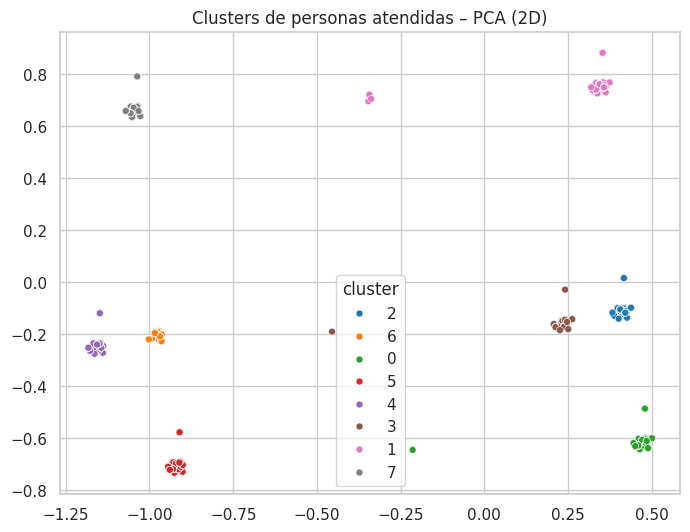

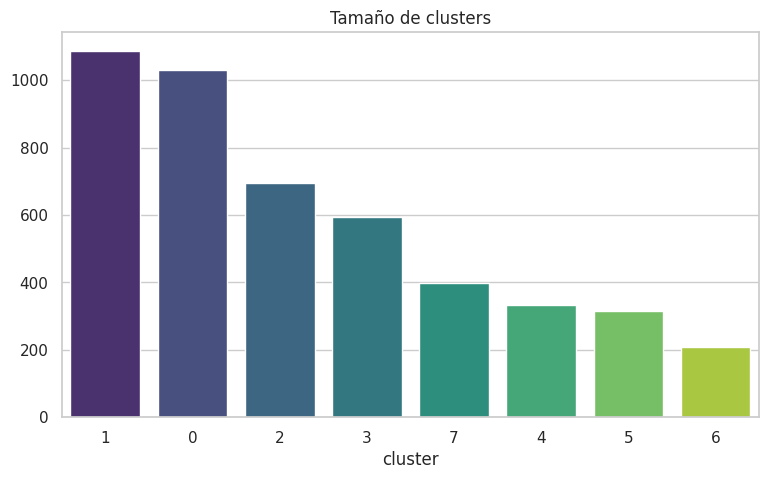


📁 Exportado: /content/clusters_personas.xlsx


In [ ]:
# ======================================================
# CLUSTERING DE PERFILES – Personas atendidas (PERFIL 99999 ELIMINADO + FIX OHE)
# ======================================================

!pip install scikit-learn umap-learn --quiet

import pandas as pd
import numpy as np
import re, warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (9,5)
sns.set(style="whitegrid", palette="viridis", font_scale=1.0)

# -------------------------------
# 1) Cargar base y detectar columnas
# -------------------------------
RUTA = "/content/base_limpia.xlsx"
df = pd.read_excel(RUTA)
print(f"✅ Base cargada: {df.shape[0]} filas, {df.shape[1]} columnas")

cols = df.columns

col_perfil = next((c for c in cols if re.search("perfil", c, re.I)), None)
col_interv = next((c for c in cols if re.search("interv", c, re.I)), None)
col_desv   = next((c for c in cols if re.search("desvinc", c, re.I)), None)
col_loc    = next((c for c in cols if re.search("local|municip|depart", c, re.I)), None)

fecha_cols = [c for c in cols if re.search(r"fecha", c, re.I) and re.search(r"seguim", c, re.I)]
for name in ["fecha_seguimiento",
             "fecha_seguimiento_cierre",
             "fecha_reposicion_de_psicologo_o_trabajador_social_posterior_al_seguimiento_cierre"]:
    c = next((x for x in cols if str(x).lower()==name.lower()), None)
    if c and c not in fecha_cols:
        fecha_cols.append(c)

print("🔎 Detectadas:")
print(" - Perfil:", col_perfil)
print(" - Tipo intervención (puede ser fecha):", col_interv)
print(" - Desvinculación:", col_desv)
print(" - Localización:", col_loc)
print(" - Fechas de seguimiento:", fecha_cols)

# -------------------------------
# 2) Preparación mínima
# -------------------------------
# Filtro perfil = 99999
if col_perfil:
    df[col_perfil] = df[col_perfil].astype(str).str.strip()
    before = len(df)
    df = df[df[col_perfil] != "99999"].copy()
    print(f"🧹 Filtro perfil=99999 → {before-len(df)} filas removidas. Quedan {len(df)}.")

# Desvinculación -> 0/1
if col_desv:
    df[col_desv] = df[col_desv].astype(str).str.lower().str.strip()
    map_desv = {"si":1, "sí":1, "1":1, "true":1, "no":0, "0":0, "false":0}
    df["desv_flag"] = df[col_desv].map(map_desv).fillna(0).astype(int)
else:
    df["desv_flag"] = 0

# n_seguimientos desde fechas
if fecha_cols:
    for c in fecha_cols:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)
    df["n_seguimientos"] = df[fecha_cols].notna().sum(axis=1).astype(int)
else:
    df["n_seguimientos"] = 0

# -------------------------------
# 3) Selección de variables
# -------------------------------
cand_edad = next((c for c in cols if re.search("edad|years|age", c, re.I)), None)
cand_estrato = next((c for c in cols if re.search("estrato", c, re.I)), None)

num_feats = ["n_seguimientos"]
if cand_edad: num_feats.append(cand_edad)
if cand_estrato: num_feats.append(cand_estrato)

cat_low, cat_high = [], []

for c in [col_perfil, col_loc]:
    if c and c in df.columns:
        nun = df[c].nunique(dropna=True)
        (cat_low if nun<=20 else cat_high).append(c)

# col_interv → convertir a mes (YYYY-MM) si es datetime
interv_feat = None
if col_interv and col_interv in df.columns:
    try:
        tmp = pd.to_datetime(df[col_interv], errors="coerce", dayfirst=True)
        if tmp.notna().any():
            df["interv_mes"] = tmp.dt.to_period("M").astype(str)
            interv_feat = "interv_mes"
        else:
            interv_feat = col_interv
    except Exception:
        interv_feat = col_interv

if interv_feat:
    nun = df[interv_feat].nunique(dropna=True)
    (cat_low if nun<=20 else cat_high).append(interv_feat)

# Limpiar y asegurar tipos
for c in num_feats:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

num_feats = [c for c in num_feats if c in df.columns]
cat_low   = [c for c in cat_low if c in df.columns]
cat_high  = [c for c in cat_high if c in df.columns]

print("\n📦 Variables seleccionadas para clustering:")
print(" - Numéricas:", num_feats)
print(" - Categóricas (baja card):", cat_low)
print(" - Categóricas (alta card → freq encoding):", cat_high)

# -------------------------------
# 4) Preprocesamiento
# -------------------------------
class FreqEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=self.columns)
        for c in self.columns:
            freq = X[c].astype(str).value_counts(dropna=False, normalize=True)
            self.maps_[c] = freq.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns)
        out = []
        for c in self.columns:
            out.append(X[c].astype(str).map(self.maps_[c]).fillna(0).values.reshape(-1,1))
        return np.hstack(out)

num_transformer = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

lowcat_transformer = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # ✅ corregido
])

highcat_transformer = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("freq", FreqEncoder(columns=cat_high))
])

transformers = []
if num_feats:   transformers.append(("num", num_transformer, num_feats))
if cat_low:     transformers.append(("lowcat", lowcat_transformer, cat_low))
if cat_high:    transformers.append(("highcat", highcat_transformer, cat_high))

preproc = ColumnTransformer(transformers=transformers, remainder="drop")

# -------------------------------
# 5) Matriz y clustering
# -------------------------------
X = preproc.fit_transform(df)

feat_names = []
if num_feats: feat_names += num_feats
if cat_low:
    ohe = preproc.named_transformers_["lowcat"].named_steps["ohe"]
    feat_names += list(ohe.get_feature_names_out(cat_low))
if cat_high:
    for c in cat_high:
        feat_names.append(f"freq__{c}")

print(f"\n🧮 Matriz final: {X.shape}")

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
print(f"🔎 Varianza explicada (PCA 2D): {pca.explained_variance_ratio_.sum():.3f}")

Ks = range(2, 9)
best_k, best_score, best_model = None, -1, None
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_try = km.fit_predict(X)
    try:
        score = silhouette_score(X, labels_try)
    except Exception:
        score = -1
    if score > best_score:
        best_k, best_score, best_model = k, score, km

if best_model is None:
    best_k, best_model = 2, KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
    best_score = -1

print(f"🏆 K óptimo: {best_k} (silhouette={best_score:.3f})")
labels = best_model.predict(X)

df = df.reset_index(drop=True).copy()
df["cluster"] = labels.astype(int)
print("Clusters:", df["cluster"].value_counts().sort_index().to_dict())

# -------------------------------
# 6) Visualizaciones
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=df["cluster"].astype(str), palette="tab10", s=25)
plt.title("Clusters de personas atendidas – PCA (2D)")
plt.show()

plt.figure()
sns.barplot(x=df["cluster"].astype(str).value_counts().index,
            y=df["cluster"].value_counts().values, palette="viridis")
plt.title("Tamaño de clusters")
plt.show()

# -------------------------------
# 7) Exportación
# -------------------------------
df[["cluster", col_perfil, col_interv, col_loc, "n_seguimientos", "desv_flag"]].to_excel(
    "/content/clusters_personas.xlsx", index=False
)
print("\n📁 Exportado: /content/clusters_personas.xlsx")
